<a href="https://colab.research.google.com/github/aburkov/theDRLbook/blob/main/gamma_dropped_rtg_reinforce_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REINFORCE in Python

In this notebook, we implement the practical reward-to-go version of REINFORCE in Python: it keeps the discounted reward-to-go target $G_t$ and drops the outer $\gamma^t$ factor from the policy-gradient term. We test it on the problem of landing a space rocket booster on a floating platform. For this, we will use the `PlatformLander` environment.

In [1]:
!command -v swig >/dev/null || (apt-get -qq update > /dev/null && apt-get -qq install -y swig > /dev/null)
!python -m pip install --no-cache-dir platform_lander==0.1.12

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.5/374.5 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.8-cp312-cp312-linux_x86_64.whl size=2381960 sha256=98606fdbd2cef219a91395fa4905c2e95646527817932654800c09b66f440a71
  Stored in directory: /tmp/pip-ephem-wheel-cache-7f66q7f_/wheels/d6/3c/ab/b6fd75459cadc56f4a4125d4cb387a708a59ca8589e4cc6b7d
Successfully built box2d-py


In [2]:
import csv
import math
import time
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.distributions import Categorical

from platform_lander import PlatformLander
from platform_lander.platform_lander import (
    BOOSTER_BOTTOM,
    BOOSTER_START_CLEARANCE,
    SCALE,
    apply_booster_initial_impulse,
    sample_booster_start_angle,
)

RUNS_DIR = Path('/content/runs') if Path('/content').exists() else Path('runs')
RUNS_DIR.mkdir(parents=True, exist_ok=True)

EPISODES = 100_000
MAX_STEPS = 400
GAMMA = 0.99
LEARNING_RATE = 1e-6
HIDDEN_DIM = 64
SEED = 0
TARGET_WINDOW = 50
PRINT_EVERY = 250
SAVE_EVERY = 1_000
NO_EARLY_STOP = False
RANDOM_BOOSTER_START_X = False

ENABLE_WIND = True
WIND_POWER = 3.0
SUCCESS_REWARD = 1000.0
FAILURE_REWARD = -300.0
SHAPING_FACTOR = 1.0
MAX_JET_FIRES = 50

LOG_FILE = RUNS_DIR / 'gamma_dropped_rtg_reinforce.log'
MODEL_FILE = RUNS_DIR / 'gamma_dropped_rtg_reinforce.pt'
BEST_MODEL_FILE = RUNS_DIR / 'gamma_dropped_rtg_reinforce_best.pt'
CSV_FILE = RUNS_DIR / 'gamma_dropped_rtg_reinforce.csv'


def platform_lander_reward_kwargs() -> dict[str, float | int]:
    return {
        'success_reward': float(SUCCESS_REWARD),
        'failure_reward': float(FAILURE_REWARD),
        'shaping_factor': float(SHAPING_FACTOR),
        'max_jet_fires': int(MAX_JET_FIRES),
    }


def platform_lander_kwargs(*, render_mode: str | None = None) -> dict[str, object]:
    kwargs: dict[str, object] = {
        'enable_wind': ENABLE_WIND,
        'wind_power': WIND_POWER,
        'wind_direction': (1.0, 0.0),
        **platform_lander_reward_kwargs(),
    }
    if render_mode is not None:
        kwargs['render_mode'] = render_mode
    return kwargs


In [3]:
import sys
import hashlib
from pathlib import Path

import torch
import numpy as np
import Box2D
import pygame
import platform_lander.platform_lander as pl
import importlib.metadata as md

print("python:", sys.version)
print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("box2d:", Box2D.__version__)
print("pygame:", pygame.version.ver)
print("platform_lander dist:", md.version("platform_lander"))
print("platform_lander file:", pl.__file__)
print("platform_lander sha256:", hashlib.sha256(Path(pl.__file__).read_bytes()).hexdigest())

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.11.0+cpu
numpy: 2.0.2
box2d: 2.3.8
pygame: 2.6.1
platform_lander dist: 0.1.12
platform_lander file: /usr/local/lib/python3.12/dist-packages/platform_lander/platform_lander.py
platform_lander sha256: 4d6df1c935ea9f556476ccfea453b72f10bf62917371cccb802573a9fc741b67


In [4]:
import hashlib
import importlib.metadata as md
from pathlib import Path
import platform_lander.platform_lander as pl

print("dist version:", md.version("platform_lander"))
print("file:", pl.__file__)
print("sha256:", hashlib.sha256(Path(pl.__file__).read_bytes()).hexdigest())


dist version: 0.1.12
file: /usr/local/lib/python3.12/dist-packages/platform_lander/platform_lander.py
sha256: 4d6df1c935ea9f556476ccfea453b72f10bf62917371cccb802573a9fc741b67


## Platform Lander

The environment contains a reusable booster falling from space and a moving ocean platform where the booster should land. The booster has three controllable jets: one main jet at the bottom and two smaller attitude-control jets near the top, one on each side. Firing the bottom jet pushes the booster upward and helps slow its descent. Firing one of the top side jets creates a torque, rotating the booster clockwise or counterclockwise. The agent must learn when to fire these jets so that the booster descends slowly, stays upright, tracks the moving platform, and lands vertically.

![](https://raw.githubusercontent.com/aburkov/theDRLbook/main/test_environments/platform_lander/booster_landing_stages.png)

The platform floats on the ocean and moves horizontally from left to right and back again. If the booster lands upright on the platform with low enough speed, the episode is considered successful. If it misses the platform and falls into the ocean, flies out of bounds, hits the platform with its body, or settles away from the platform, the episode fails.

The environment also includes wind. This notebook uses the same environment configuration as the validation experiments in the chapter: wind is enabled and blows horizontally with power $3.0$, so the environment pushes the booster around in ways the agent cannot predict. The booster has $50$ available jet fires, so the agent cannot simply keep firing forever; it must learn to use thrust efficiently while guiding the booster toward the moving platform.

Rewards in this environment are designed to encourage the booster to approach the platform, slow down, stay upright, and conserve fuel.

At each step, the environment computes a shaping score based on the current state. The score subtracts horizontal distance from the platform, vertical distance when the booster bottom is over the platform, horizontal and vertical speed, tilt, and angular velocity. It also gives a bonus of $12$ when the left landing foot touches the platform and another bonus of $12$ when the right landing foot touches the platform.

The actual dense per-step reward is `SHAPING_FACTOR` times the change in this shaping score from the previous step. So the agent receives positive reward when it improves its situation, and negative reward when it gets farther from a good landing state.

There is also a small fuel penalty whenever a jet is fired. Firing the bottom jet subtracts $0.30$, and firing one of the top attitude-control jets subtracts $0.03$.

Finally, terminal rewards are assigned at the end of an episode:

- successful vertical landing: $+1000$, multiplied by an impact-speed multiplier (a gentle touchdown earns the full reward; harder but still acceptable touchdowns earn as little as a quarter of it)
- failure: $-300$

These values—wind power $3.0$, $50$ jet fires, success reward $+1000$, failure reward $-300$, and shaping factor $1.0$—are the same ones used by the validation scripts whose results are reported in the chapter's Validation Results section.


## Training a Platform Lander with Reward-to-Go REINFORCE

The `PlatformLander` environment has a discrete action space with four actions:

```text
0: do nothing
1: fire the upper-left attitude jet
2: fire the bottom engine
3: fire the upper-right attitude jet
```

The observation is an 11-dimensional vector. It contains:

```text
0: booster x-position relative to the platform, normalized by half the viewport width
1: booster y-position relative to the target landing height, normalized by half the viewport height
2: booster x-velocity relative to the platform x-velocity, scaled by half viewport width / FPS
3: booster y-velocity, scaled by half viewport height / FPS
4: booster angle, normalized to [-pi, pi]
5: booster angular velocity, scaled by 20 / FPS
6: left landing foot contact flag, 1 if touching, else 0
7: right landing foot contact flag, 1 if touching, else 0
8: platform x-position, normalized relative to half the viewport width
9: platform x-velocity
10: fraction of jet fires remaining
```

In [5]:
env = PlatformLander(**platform_lander_kwargs())
observation, info = env.reset(seed=SEED)

print('observation_space:', env.observation_space)
print('action_space:', env.action_space)
print('initial observation shape:', observation.shape)
print('initial observation:', np.round(observation, 3))

env.close()


observation_space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
   0.          0.         -1.         -2.          0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.         1.         2.         1.       ], (11,), float32)
action_space: Discrete(4)
initial observation shape: (11,)
initial observation: [ 0.     1.474 -0.416  0.147  0.032  0.     0.     0.    -0.358  0.383
  1.   ]


Now we define the policy neural network:

In [6]:
def init_layer(layer, gain=math.sqrt(2), bias_const=0):
    nn.init.orthogonal_(layer.weight, gain) # ➊
    nn.init.constant_(layer.bias, bias_const)
    return layer

class Policy(nn.Module):
    def __init__(self, obs_dim, act_dim, hid_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            init_layer(nn.Linear(obs_dim, hid_dim), math.sqrt(2)), # ➋
            nn.Tanh(), # ➌
            init_layer(nn.Linear(hid_dim, hid_dim), math.sqrt(2)), # ➍
            nn.Tanh(),
            init_layer(nn.Linear(hid_dim, act_dim), 0.01), # ➎
        )

    def forward(self, obs):
        return self.net(obs)

In the above code:

- Line ➊ initializes the linear layer's parameters. The initializer uses the **orthogonal initialization**\index{initialization!orthogonal} with the `gain` parameter set to $\sqrt{2}$; this starts each linear layer with weight directions that are well separated from one another, which is a common choice in REINFORCE implementations.
- In line ➋, the network maps the observation vector to a hidden representation, using the $\sqrt{2}$ gain for a `Tanh` policy network.
- In line ➌, it applies a `Tanh` nonlinearity to the hidden representation.
- In line ➍, the network applies a second hidden layer, again using the $\sqrt{2}$ gain.
- In line ➎, the network outputs one logit for each possible action, using a small gain of $0.01$ so the initial categorical policy is close to uniform.

Now we define a function that will sample an action from the policy:

In [7]:
def sample_action(policy: Policy, observation: np.ndarray, *, train: bool = True) -> int:
    obs_tensor = torch.as_tensor(observation, dtype=torch.float32)  # ➊
    logits = policy(obs_tensor)  # ➋
    dist = Categorical(logits=logits)  # ➌

    if train:
        action_tensor = dist.sample()  # ➍
    else:
        action_tensor = torch.argmax(logits)

    return int(action_tensor.item())


# Tiny check with an untrained policy.
env = PlatformLander(**platform_lander_kwargs())
observation, _ = env.reset(seed=SEED)
policy = Policy(
    int(env.observation_space.shape[0]),
    int(env.action_space.n),
    HIDDEN_DIM,
)
action = sample_action(policy, observation)
print('sampled action:', action)
env.close()


sampled action: 3


In the code above:

- In line ➊, we convert the NumPy observation into a float32 tensor so it can be passed through the policy network. `torch.as_tensor` reuses the underlying buffer when possible instead of copying.
- In line ➋, the policy network maps the observation to one logit per action.
- In line ➌, we build a `Categorical` distribution directly from the logits, so PyTorch normalizes them with a numerically stable log-softmax internally.
- In line ➍, during training we sample an action from this distribution, which gives the agent its exploration; during evaluation (`train=False`) we instead take the greedy action `argmax(logits)`.

The function returns the chosen action as a plain integer, ready to pass to `env.step`.

During one episode, we store all observations, log-probabilities, and rewards:

In [8]:
def randomize_start(
    env: PlatformLander,
    rng: np.random.Generator,
    *,
    random_booster_start_x: bool = False,
) -> np.ndarray:
    """Randomize the platform and optionally the booster x position."""
    assert env.booster is not None
    assert env.platform is not None

    h = 400 / 30.0

    env.platform.position = (
        float(rng.uniform(env.platform_min_x, env.platform_max_x)),
        env.platform_y,
    )
    env.platform_direction = int(rng.choice([-1, 1]))
    env.platform.linearVelocity = (
        env.platform_speed * env.platform_direction,
        0.0,
    )

    booster_x = (
        float(rng.uniform(env.platform_min_x, env.platform_max_x))
        if random_booster_start_x
        else float(env.platform.position.x)
    )
    env.booster.position = (
        booster_x,
        float(h + BOOSTER_BOTTOM / SCALE + BOOSTER_START_CLEARANCE),
    )
    env.booster.angle = sample_booster_start_angle(rng)
    env.booster.linearVelocity = (0.0, 0.0)
    env.booster.angularVelocity = 0.0
    apply_booster_initial_impulse(env.booster, rng)
    env.booster.awake = True

    env.ocean_contact = False
    env.platform_contact = False
    env.body_platform_contact = False
    env.left_foot_contact = False
    env.right_foot_contact = False
    env.failure_reason = None
    env.prev_shaping = None
    env.bottom_flame_power = 0.0
    env.top_flame_power = 0.0
    env.top_flame_direction = 0
    env.jet_fires_used = 0
    return env._get_state()


def discounted_return(rewards: list[float], gamma: float) -> float:
    total = 0.0
    discount = 1.0
    for reward in rewards:
        total += discount * reward
        discount *= gamma
    return total


def run_episode_data(
    env: PlatformLander,
    policy: Policy,
    rng: np.random.Generator,
    *,
    gamma: float,
    max_steps: int,
    train: bool,
    random_booster_start_x: bool = False,
    reset_seed: int | None = None,
    start_seed: int | None = None,
) -> tuple[list[torch.Tensor], list[torch.Tensor], list[float], float, int, dict]:
    if reset_seed is None:
        reset_seed = int(rng.integers(0, 2**31 - 1))
    start_rng = np.random.default_rng(start_seed) if start_seed is not None else rng

    observation, _ = env.reset(seed=reset_seed)
    observation = randomize_start(
        env,
        start_rng,
        random_booster_start_x=random_booster_start_x,
    )

    observations: list[torch.Tensor] = []
    log_probs: list[torch.Tensor] = []
    rewards: list[float] = []
    entropies: list[float] = []
    info: dict = {}

    for step in range(max_steps):
        obs_tensor = torch.as_tensor(observation, dtype=torch.float32)
        observations.append(obs_tensor)  # ➊
        logits = policy(obs_tensor)
        dist = Categorical(logits=logits)

        if train:
            action_tensor = dist.sample()
        else:
            action_tensor = torch.argmax(logits)

        action = int(action_tensor.item())
        log_probs.append(dist.log_prob(action_tensor))  # ➋
        entropies.append(float(dist.entropy().detach().item()))

        observation, reward, terminated, truncated, info = env.step(action)  # ➌
        rewards.append(float(reward))  # ➍

        if terminated or truncated:
            break

    if not terminated and not truncated:
        rewards[-1] = float(env.failure_reward)
        info = {
            **info,
            'success': False,
            'failure_reason': 'timeout',
        }

    average_entropy = float(np.mean(entropies)) if entropies else 0.0
    info = {
        **info,
        'policy_entropy': average_entropy,
        'policy_perplexity': float(math.exp(average_entropy)),
    }

    episode_return = discounted_return(rewards, gamma)
    return observations, log_probs, rewards, episode_return, step + 1, info


In the code above:

- In line ➊, we store the observation tensor.
- In line ➋, we store the log-probability of the action actually taken.
- In line ➌, the environment applies the action to the booster physics.
- In line ➍, we store the reward returned by the environment.

The training script starts every episode from a randomized platform position and direction, then places the booster above the platform unless `RANDOM_BOOSTER_START_X` is enabled. It samples the initial booster angle and applies the environment's initial impulse.


After the episode ends, we compute a reward-to-go value for every timestep:

In [9]:
def rewards_to_go(rewards: list[float], gamma: float) -> torch.Tensor:
    returns = []
    running_return = 0.0

    for reward in reversed(rewards):
        running_return = reward + gamma * running_return  # ➊
        returns.append(running_return)

    returns.reverse()  # ➋
    return torch.as_tensor(returns, dtype=torch.float32)

In line ➊ above, we walk backward through the episode and apply the recursion $G_t=r_{t+1}+\gamma G_{t+1}$. In line ➋, we reverse the list so `returns[t]` corresponds to the same timestep as `log_probs[t]`.

This implements:

$$
G_t=\sum_{k=t}^{T-1}\gamma^{k-t}r_{k+1}.
$$

Now we can form the reward-to-go REINFORCE loss:

In [10]:
def reward_to_go_loss(
    log_probs: list[torch.Tensor],
    rewards: list[float],
    *,
    gamma: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    rtg = rewards_to_go(rewards, gamma)  # ➊
    log_prob_tensor = torch.stack(log_probs).reshape(-1)  # ➋

    rtg = rtg.to(device=log_prob_tensor.device, dtype=log_prob_tensor.dtype)

    assert log_prob_tensor.shape == rtg.shape

    policy_loss = -(log_prob_tensor * rtg).sum()  # ➌
    loss = policy_loss
    return loss, policy_loss

In the code above:

- In line ➊, `rtg[t]` stores $G_t$, the reward-to-go from timestep $t$.
- In line ➋, we turn the collected log-probabilities into a vector.
- In line ➌, we form $-\sum_{t=0}^{T-1}\log\pi_\mathbf{\theta}(a_t\mid o_t)G_t$, with no outer $\gamma^t$ factor.

The reason for the minus sign is that PyTorch's optimizers are designed to minimize a loss function by following the negative gradient. This is a typical scenario in supervised learning when we train neural networks to minimize the loss of making wrong prediction. In reinforcement learning, however, our goal is to maximize the expected total reward $J(\mathbf{\theta})$, not minimize it.

To apply the practical update using a minimizer, we minimize its negative. The exact gradient of the discounted objective would include the outer $\gamma^t$ factor derived earlier, but this implementation follows the gamma-dropped update described in the previous section. We could implement our own gradient ascent optimizer, but it is much simpler to reuse PyTorch's well-tested optimizers by negating the quantity whose gradient we want to ascend. Therefore, we define our policy loss as $-\sum_{t=0}^{T-1}\log\pi_\mathbf{\theta}(a_t\mid o_t)G_t$.

So minimizing this loss is equivalent to applying the update:

$$
\mathbf{\theta}
\leftarrow
\mathbf{\theta}
+
\alpha
\sum_{t=0}^{T-1}
\nabla_\mathbf{\theta}
\log \pi_\mathbf{\theta}(a_t \mid o_t)
G_t.
$$


Finally, we perform the optimization step:

In [11]:
def training_args() -> dict[str, object]:
    return {
        'episodes': EPISODES,
        'max_steps': MAX_STEPS,
        'gamma': GAMMA,
        'learning_rate': LEARNING_RATE,
        'hidden_dim': HIDDEN_DIM,
        'seed': SEED,
        'target_window': TARGET_WINDOW,
        'print_every': PRINT_EVERY,
        'save_every': SAVE_EVERY,
        'wind': ENABLE_WIND,
        'wind_power': WIND_POWER,
        'no_early_stop': NO_EARLY_STOP,
        'random_booster_start_x': RANDOM_BOOSTER_START_X,
        'success_reward': SUCCESS_REWARD,
        'failure_reward': FAILURE_REWARD,
        'shaping_factor': SHAPING_FACTOR,
        'max_jet_fires': MAX_JET_FIRES,
        'log_file': str(LOG_FILE),
        'model_file': str(MODEL_FILE),
        'best_model_file': str(BEST_MODEL_FILE),
        'csv_file': str(CSV_FILE),
    }


def open_log(log_file: Path):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    return log_file.open('w', encoding='utf-8')


def log(message: str, log_file=None) -> None:
    print(message)
    if log_file is not None:
        log_file.write(message + '\n')
        log_file.flush()


def save_training_csv(rows: list[dict[str, object]], csv_file: Path) -> Path:
    csv_file.parent.mkdir(parents=True, exist_ok=True)
    fieldnames: list[str] = []
    for row in rows:
        for key in row:
            if key not in fieldnames:
                fieldnames.append(key)

    with csv_file.open('w', encoding='utf-8', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    return csv_file


def save_policy(policy: Policy, model_file: Path, *, obs_dim: int, action_dim: int) -> Path:
    model_file.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'policy_state_dict': policy.state_dict(),
            'obs_dim': obs_dim,
            'action_dim': action_dim,
            'hidden_dim': HIDDEN_DIM,
            'args': training_args(),
        },
        model_file,
    )
    return model_file


def save_checkpoint(
    policy: Policy,
    training_rows: list[dict[str, object]],
    *,
    obs_dim: int,
    action_dim: int,
    log_file,
    episode: int,
) -> tuple[Path, Path]:
    model_path = save_policy(policy, MODEL_FILE, obs_dim=obs_dim, action_dim=action_dim)
    csv_path = save_training_csv(training_rows, CSV_FILE)
    log(f'saved_checkpoint episode={episode} model_file={model_path} csv_file={csv_path}', log_file)
    return model_path, csv_path


def save_best_checkpoint(
    policy: Policy,
    *,
    obs_dim: int,
    action_dim: int,
    log_file,
    episode: int,
    success_count: int,
    average_return: float,
) -> Path:
    best_model_path = save_policy(policy, BEST_MODEL_FILE, obs_dim=obs_dim, action_dim=action_dim)
    log(
        f'saved_best_checkpoint episode={episode} '
        f'success{TARGET_WINDOW}={success_count} '
        f'avg{TARGET_WINDOW}={average_return:.2f} '
        f'model_file={best_model_path}',
        log_file,
    )
    return best_model_path


def clear_existing_best_checkpoint(log_file) -> None:
    if BEST_MODEL_FILE.exists():
        BEST_MODEL_FILE.unlink()
        log(f'cleared_best_checkpoint model_file={BEST_MODEL_FILE}', log_file)


def train() -> tuple[Policy, pd.DataFrame]:
    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)

    env = PlatformLander(**platform_lander_kwargs())

    policy = Policy(
        int(env.observation_space.shape[0]),
        int(env.action_space.n),
        HIDDEN_DIM,
    )
    obs_dim = int(env.observation_space.shape[0])
    action_dim = int(env.action_space.n)

    optimizer = torch.optim.SGD(policy.parameters(), lr=LEARNING_RATE)

    recent_returns: deque[float] = deque(maxlen=TARGET_WINDOW)
    recent_successes: deque[bool] = deque(maxlen=TARGET_WINDOW)
    recent_jet_fires: deque[int] = deque(maxlen=TARGET_WINDOW)
    recent_entropies: deque[float] = deque(maxlen=TARGET_WINDOW)

    training_rows: list[dict[str, object]] = []
    log_file = open_log(LOG_FILE)
    model_path: Path | None = None
    best_model_path: Path | None = None
    csv_path: Path | None = None
    completed_episode = 0
    last_saved_episode = 0
    best_success_count = 0
    learning_started_at = time.perf_counter()
    elapsed_seconds = 0.0

    try:
        log(
            f'training_start script=gamma_dropped_rtg_reinforce '
            f'episodes={EPISODES} max_steps={MAX_STEPS} seed={SEED} '
            f'model_file={MODEL_FILE}',
            log_file,
        )
        clear_existing_best_checkpoint(log_file)

        for episode in range(1, EPISODES + 1):
            observations, log_probs, rewards, episode_return, steps, info = run_episode_data(
                env,
                policy,
                rng,
                gamma=GAMMA,
                max_steps=MAX_STEPS,
                train=True,
                random_booster_start_x=RANDOM_BOOSTER_START_X,
            )

            loss, policy_loss = reward_to_go_loss(
                log_probs,
                rewards,
                gamma=GAMMA,
            )

            recent_returns.append(episode_return)
            recent_successes.append(bool(info.get('success', False)))
            recent_jet_fires.append(int(info.get('jet_fires_used', 0)))
            policy_entropy = float(info.get('policy_entropy', 0.0))
            recent_entropies.append(policy_entropy)

            average_return = float(np.mean(recent_returns))
            success_count = int(sum(recent_successes))
            average_jet_fires = float(np.mean(recent_jet_fires))
            average_entropy = float(np.mean(recent_entropies))
            effective_actions = float(math.exp(policy_entropy))
            average_effective_actions = float(math.exp(average_entropy))

            training_rows.append(
                {
                    'episode': episode,
                    'return': episode_return,
                    'average_return': average_return,
                    'policy_loss': float(policy_loss.detach().item()),
                    'loss': float(loss.detach().item()),
                    'success_count': success_count,
                    'success_rate': success_count / len(recent_successes),
                    'jet_fires': int(info.get('jet_fires_used', 0)),
                    'average_jet_fires': average_jet_fires,
                    'policy_entropy': policy_entropy,
                    'average_policy_entropy': average_entropy,
                    'effective_actions': effective_actions,
                    'average_effective_actions': average_effective_actions,
                    'steps': steps,
                    'success': bool(info.get('success', False)),
                    'failure_reason': info.get('failure_reason'),
                }
            )
            completed_episode = episode

            full_success_window = len(recent_successes) == TARGET_WINDOW
            improved_best = full_success_window and success_count > best_success_count
            if improved_best:
                best_success_count = success_count
                best_model_path = save_best_checkpoint(
                    policy,
                    obs_dim=obs_dim,
                    action_dim=action_dim,
                    log_file=log_file,
                    episode=episode,
                    success_count=success_count,
                    average_return=average_return,
                )

            if full_success_window and success_count == TARGET_WINDOW and not NO_EARLY_STOP:
                log(
                    f'early_stop episode={episode} '
                    f'success{TARGET_WINDOW}={success_count} '
                    f'avg{TARGET_WINDOW}={average_return:.2f} '
                    f'best_model_file={best_model_path}',
                    log_file,
                )
                break

            if episode == 1 or episode % PRINT_EVERY == 0:
                log(
                    f'episode={episode:5d} '
                    f'return={episode_return:8.2f} '
                    f'avg{len(recent_returns):02d}={average_return:8.2f} '
                    f'success{len(recent_successes):02d}={success_count:2d} '
                    f'fires={info.get("jet_fires_used", 0):3d} '
                    f'avgfires{len(recent_jet_fires):02d}={average_jet_fires:6.1f} '
                    f'entropy={policy_entropy:5.3f} '
                    f'effact={effective_actions:4.2f} '
                    f'avgeff{len(recent_entropies):02d}={average_effective_actions:4.2f} '
                    f'steps={steps:4d} '
                    f'failure={info.get("failure_reason")}',
                    log_file,
                )

            optimizer.zero_grad()  # ➊
            loss.backward()  # ➋
            optimizer.step()  # ➌

            if SAVE_EVERY and episode % SAVE_EVERY == 0:
                model_path, csv_path = save_checkpoint(
                    policy,
                    training_rows,
                    obs_dim=obs_dim,
                    action_dim=action_dim,
                    log_file=log_file,
                    episode=episode,
                )
                last_saved_episode = episode

    except KeyboardInterrupt:
        log(f'training_interrupted episode={completed_episode}', log_file)

    finally:
        if training_rows and completed_episode != last_saved_episode:
            model_path, csv_path = save_checkpoint(
                policy,
                training_rows,
                obs_dim=obs_dim,
                action_dim=action_dim,
                log_file=log_file,
                episode=completed_episode,
            )
        elapsed_seconds = time.perf_counter() - learning_started_at
        if training_rows:
            training_rows[-1]['elapsed_seconds'] = elapsed_seconds
        log(
            f'learning_finished episode={completed_episode} '
            f'elapsed_seconds={elapsed_seconds:.2f} '
            f'elapsed_minutes={elapsed_seconds / 60.0:.2f}',
            log_file,
        )
        env.close()
        log_file.close()

    if not training_rows or model_path is None or csv_path is None:
        raise RuntimeError('training produced no episodes to save')

    return policy, pd.DataFrame(training_rows)


In the code above:

- In line ➊, we clear gradients from the previous episode.
- In line ➋, PyTorch computes the gradient of the loss.
- In line ➌, stochastic gradient descent updates the policy parameters.

Run the training cell below. The hyperparameters match the validation scripts used for the chapter's Validation Results section: $100{,}000$ episodes, learning rate $10^{-6}$, and seed $0$, so a full run is intentionally long. For a quick demonstration, change `EPISODES` near the top of the notebook to a smaller value such as `200` or `1_000`, then run the training cell.

The notebook stops early once the policy lands successfully $50$ times in a row; set `NO_EARLY_STOP = True` to train through the full episode budget like the validation runs.

In [12]:
policy, history = train()
history.tail()

training_start script=gamma_dropped_rtg_reinforce episodes=100000 max_steps=400 seed=0 model_file=/content/runs/gamma_dropped_rtg_reinforce.pt
episode=    1 return= -355.30 avg01= -355.30 success01= 0 fires= 50 avgfires01=  50.0 entropy=1.386 effact=4.00 avgeff01=4.00 steps= 400 failure=timeout
saved_best_checkpoint episode=240 success50=1 avg50=-239.28 model_file=/content/runs/gamma_dropped_rtg_reinforce_best.pt
episode=  250 return= -208.73 avg50= -247.76 success50= 1 fires= 50 avgfires50=  50.0 entropy=1.316 effact=3.73 avgeff50=3.80 steps= 233 failure=booster_body_hit_platform
episode=  500 return= -156.32 avg50= -233.22 success50= 1 fires= 50 avgfires50=  50.0 entropy=1.342 effact=3.82 avgeff50=3.83 steps= 224 failure=ocean
episode=  750 return= -404.63 avg50= -217.29 success50= 0 fires= 50 avgfires50=  50.0 entropy=1.347 effact=3.84 avgeff50=3.77 steps= 104 failure=out_of_bounds
saved_best_checkpoint episode=835 success50=2 avg50=-204.61 model_file=/content/runs/gamma_dropped_rtg

,episode,return,average_return,policy_loss,loss,success_count,success_rate,jet_fires,average_jet_fires,policy_entropy,average_policy_entropy,effective_actions,average_effective_actions,steps,success,failure_reason,elapsed_seconds
99995,99996,409.980180,315.969158,34053.515625,34053.515625,41,0.82,40,46.92,0.603997,0.582209,1.829417,1.789988,79,True,None,NaN
99996,99997,464.904241,317.421177,35062.277344,35062.277344,41,0.82,46,46.98,0.551819,0.580621,1.736408,1.787148,69,True,None,NaN
99997,99998,373.044818,317.458341,27251.123047,27251.123047,41,0.82,48,46.94,0.584271,0.579778,1.793682,1.785642,85,True,None,NaN
99998,99999,431.126345,318.195035,24600.375000,24600.375000,41,0.82,41,46.94,0.535936,0.577153,1.709046,1.780960,72,True,None,NaN
99999,100000,267.808844,316.101887,9317.790039,9317.790039,41,0.82,50,46.94,0.327606,0.573300,1.387642,1.774112,69,True,None,13888.243275


After training, we can watch the learned policy fly. The below cell rolls out one greedy episode and renders it as an inline animation.

- `rollout_frames` runs a single evaluation episode. It puts the policy in `eval` mode, builds the environment with `render_mode='rgb_array'`, and randomizes the start exactly as in training. Acting greedily under `torch.no_grad()`, it steps the environment, collecting both the per-step `rewards` and the rendered RGB `frames`. As elsewhere, if the episode neither terminates nor truncates within `max_steps`, the last reward is overwritten with the failure reward and the episode is marked a timeout.
- `show_rollout` calls `rollout_frames`, prints the discounted return, undiscounted reward sum, step count, and `info`, then animates the collected frames with Matplotlib's `FuncAnimation` and displays the result inline via `HTML`.

In [13]:
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation


def rollout_frames(
    policy: Policy,
    *,
    seed: int = SEED + 10_000,
    max_steps: int = MAX_STEPS,
) -> tuple[list[np.ndarray], list[float], float, dict]:
    policy.eval()
    rng = np.random.default_rng(seed)
    env = PlatformLander(**platform_lander_kwargs(render_mode='rgb_array'))

    frames: list[np.ndarray] = []
    rewards: list[float] = []
    info: dict = {}
    terminated = False
    truncated = False

    try:
        observation, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
        observation = randomize_start(
            env,
            rng,
            random_booster_start_x=RANDOM_BOOSTER_START_X,
        )

        with torch.no_grad():
            for _ in range(max_steps):
                action = sample_action(policy, observation, train=False)
                observation, reward, terminated, truncated, info = env.step(action)
                rewards.append(float(reward))
                frames.append(env.render())

                if terminated or truncated:
                    break

        if rewards and not terminated and not truncated:
            rewards[-1] = float(env.failure_reward)
            info = {
                **info,
                'success': False,
                'failure_reason': 'timeout',
            }
    finally:
        env.close()

    return frames, rewards, discounted_return(rewards, GAMMA), info


def show_rollout(policy: Policy, *, fps: int = 30) -> None:
    frames, rewards, episode_return, info = rollout_frames(policy)

    print(
        f'evaluation_return={episode_return:.2f} '
        f'undiscounted={sum(rewards):.2f} '
        f'steps={len(rewards)} '
        f'info={info}'
    )

    if not frames:
        print('No frames were rendered.')
        return

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')
    image = ax.imshow(frames[0])

    def update(frame: np.ndarray):
        image.set_data(frame)
        return (image,)

    anim = FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=1000 / fps,
        blit=True,
    )
    plt.close(fig)
    display(HTML(anim.to_jshtml()))


show_rollout(policy)


evaluation_return=398.48 undiscounted=945.85 steps=87 info={'success': True, 'failure_reason': None, 'platform_x': 9.479243278503418, 'platform_impact_velocity': (2.3076902627944946, -5.91450834274292, -0.7508031725883484), 'success_reward_multiplier': 0.8244818449020386, 'wind_power': 3.0, 'wind_direction': (1.0, 0.0), 'jet_fires_used': 42, 'jet_fires_remaining': 8, 'stable_landing_steps': 0, 'anchored_feet': ('left_foot', 'right_foot'), 'left_foot_contact': True, 'right_foot_contact': True, 'body_platform_contact': False, 'platform_contact': True}


To see how learning progressed, we plot the training history collected in the `history` DataFrame. The left panel shows the per-episode return (faint) together with its moving average over the last `TARGET_WINDOW` episodes, so the trend is visible through the noise. The right panel shows the success rate over the same trailing window, on a fixed $[0, 1]$ axis. Together they tell you whether returns are climbing and whether that translates into actual successful landings.

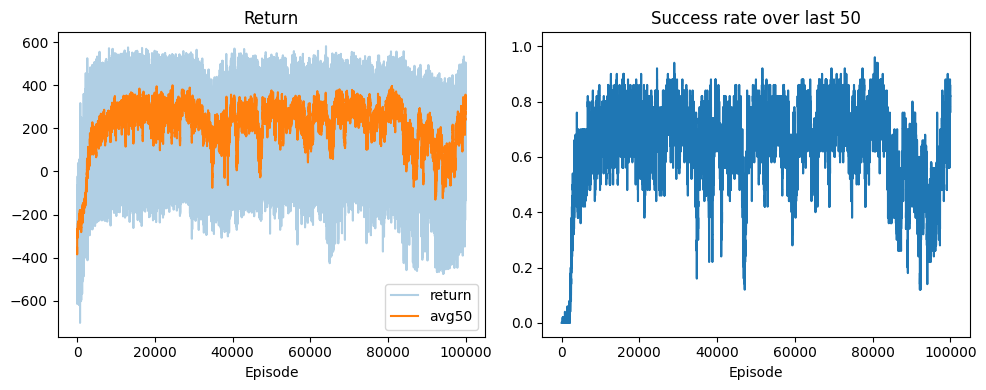

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history['episode'], history['return'], alpha=0.35, label='return')
axes[0].plot(history['episode'], history['average_return'], label=f'avg{TARGET_WINDOW}')
axes[0].set_title('Return')
axes[0].set_xlabel('Episode')
axes[0].legend()

axes[1].plot(history['episode'], history['success_rate'])
axes[1].set_title(f'Success rate over last {TARGET_WINDOW}')
axes[1].set_xlabel('Episode')
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()